In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
)
import xgboost as xgb
import shap


## 5.  Preprocessing Pipeline


In [32]:
job_map = {"< 1 year": 0, "1 year": 1, "2 years": 2, "3 years": 3,
           "4 years": 4,  "5 years": 5, "6 years": 6, "7 years": 7,
           "8 years": 8,  "9 years": 9, "10+ years": 10}

In [33]:
df_feat = pd.read_csv("../data/credit_eda.csv")

In [34]:
SEED = 42

#  Feature selection
FEATURES = [
    # Numeric
    "Credit Score", "Annual Income", "Current Loan Amount",
    "Monthly Debt", "Years of Credit History", "Employment Years",
    "Number of Open Accounts", "Number of Credit Problems",
    "Current Credit Balance", "Maximum Open Credit",
    "Bankruptcies", "Tax Liens",
    # Engineered
    "DTI Ratio", "Loan To Income", "Credit Utilization",
    "Has Delinquent", "Is Owner",
    # Categorical (will be encoded)
    "Term", "Home Ownership", "Purpose",
]

NUMERIC_COLS = [
    "Credit Score", "Annual Income", "Current Loan Amount",
    "Monthly Debt", "Years of Credit History", "Employment Years",
    "Number of Open Accounts", "Number of Credit Problems",
    "Current Credit Balance", "Maximum Open Credit",
    "Bankruptcies", "Tax Liens",
    "DTI Ratio", "Loan To Income", "Credit Utilization",
    "Has Delinquent", "Is Owner",
]

CATEGORICAL_COLS = ["Term", "Home Ownership", "Purpose"]

TARGET = "Approved"

X = df_feat[FEATURES].copy()
y = df_feat[TARGET].copy()

#  Preprocessing sub-pipelines 
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])

categorical_transformer = Pipeline([
    ("imputer",  SimpleImputer(strategy="most_frequent")),
    ("encoder",  OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer,  NUMERIC_COLS),
    ("cat", categorical_transformer, CATEGORICAL_COLS),
])

#  Train / Test split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED)

print(f"Train size : {X_train.shape[0]:,}  ({y_train.mean():.1%} approve rate)")
print(f"Test  size : {X_test.shape[0]:,}  ({y_test.mean():.1%} approve rate)")
print(f"Features   : {len(FEATURES)} ({len(NUMERIC_COLS)} numeric + {len(CATEGORICAL_COLS)} categorical)")



Train size : 8,282  (75.9% approve rate)
Test  size : 2,071  (75.9% approve rate)
Features   : 20 (17 numeric + 3 categorical)


## 6.  Model Training & Comparison

Four models are trained and compared:
| # | Model | Strengths |
|---|-------|-----------|
| 1 | Logistic Regression | Interpretable baseline, fast |
| 2 | Random Forest | Handles non-linearity, robust to outliers |
| 3 | Gradient Boosting | Strong performance, ensemble |
| 4 | XGBoost | State-of-the-art, regularized boosting |



In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import xgboost as xgb

def build_pipeline(clf):
    return Pipeline([
        ("preprocessor", preprocessor),
        ("clf",          clf),
    ])

models = {
    "Logistic Regression": build_pipeline(
        LogisticRegression(max_iter=1000, C=0.5, random_state=SEED)
    ),
    "Random Forest": build_pipeline(
        RandomForestClassifier(n_estimators=200, max_depth=12,
                               min_samples_leaf=5, random_state=SEED)
    ),
    "Gradient Boosting": build_pipeline(
        GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                   max_depth=5, random_state=SEED)
    ),
    "XGBoost": build_pipeline(
        xgb.XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=5,
                          use_label_encoder=False, eval_metric="logloss",
                          random_state=SEED, verbosity=0)
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
results = {}

print(f"{'Model':<24} {'CV AUC (mean)':<16} {'± std':<10} {'Test AUC':<10}")
print("" * 65)

for name, pipe in models.items():
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=cv,
                                scoring="roc_auc", n_jobs=-1)
    pipe.fit(X_train, y_train)
    y_pred  = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    test_auc = roc_auc_score(y_test, y_proba)
    results[name] = {
        "pipe": pipe, "y_pred": y_pred, "y_proba": y_proba,
        "cv_mean": cv_scores.mean(), "cv_std": cv_scores.std(), "test_auc": test_auc
    }
    print(f"{name:<24} {cv_scores.mean():.4f}           ±{cv_scores.std():.4f}    {test_auc:.4f}")

best_name = max(results, key=lambda k: results[k]["test_auc"])
best      = results[best_name]
print(f"\n  Best model: {best_name}  (Test AUC = {best['test_auc']:.4f})")



Model                    CV AUC (mean)    ± std      Test AUC  

Logistic Regression      0.6771           ±0.0188    0.6948
Random Forest            0.9995           ±0.0002    0.9992
Gradient Boosting        0.9987           ±0.0013    0.9997
XGBoost                  0.9997           ±0.0002    0.9995

  Best model: Gradient Boosting  (Test AUC = 0.9997)


## 7.  Model Evaluation

### 7.1 Classification Report — Best Model


In [36]:
print(f"Classification Report — {best_name}\n")
print(classification_report(y_test, best["y_pred"],
      target_names=["High Risk (Reject)", "Low Risk (Approve)"]))



Classification Report — Gradient Boosting

                    precision    recall  f1-score   support

High Risk (Reject)       0.99      0.97      0.98       500
Low Risk (Approve)       0.99      1.00      0.99      1571

          accuracy                           0.99      2071
         macro avg       0.99      0.98      0.99      2071
      weighted avg       0.99      0.99      0.99      2071



### 7.2 ROC Curves, Confusion Matrix & AUC Comparison


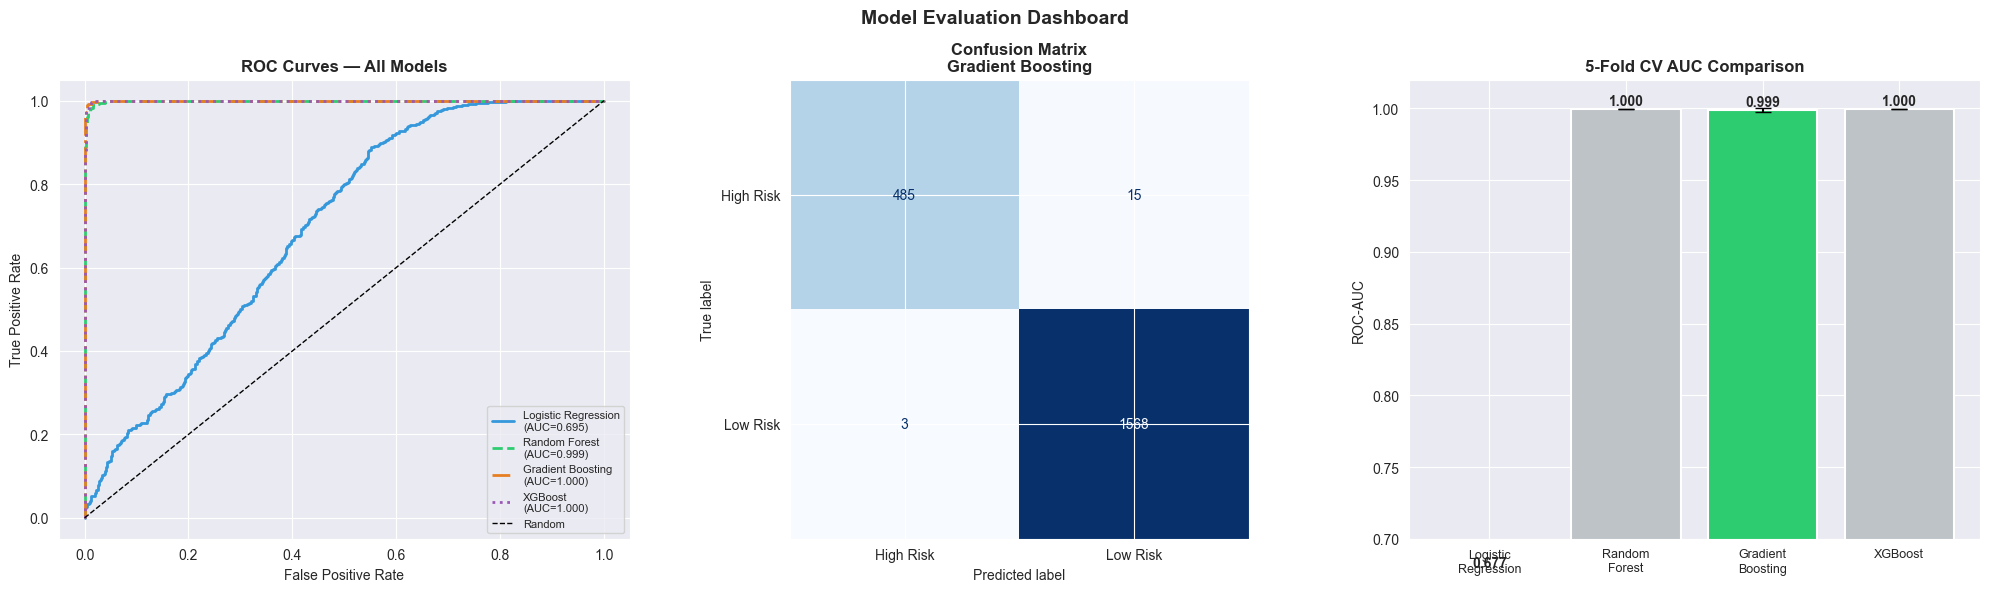

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Model Evaluation Dashboard", fontsize=14, fontweight="bold")
line_styles = ["-", "--", "-.", ":"]
colors_roc  = ["#3498DB", "#2ECC71", "#E67E22", "#9B59B6"]

#  ROC Curves 
ax = axes[0]
for (name, res), ls, col in zip(results.items(), line_styles, colors_roc):
    fpr, tpr, _ = roc_curve(y_test, res["y_proba"])
    ax.plot(fpr, tpr, lw=2, linestyle=ls, color=col,
            label=f"{name}\n(AUC={res['test_auc']:.3f})")
ax.plot([0,1],[0,1], "k--", lw=1, label="Random")
ax.set_title("ROC Curves — All Models", fontweight="bold")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.legend(fontsize=8, loc="lower right")

#  Confusion Matrix 
ax = axes[1]
cm = confusion_matrix(y_test, best["y_pred"])
disp = ConfusionMatrixDisplay(cm, display_labels=["High Risk", "Low Risk"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"Confusion Matrix\n{best_name}", fontweight="bold")

#  CV AUC Comparison 
ax = axes[2]
names  = list(results.keys())
means  = [results[n]["cv_mean"] for n in names]
stds   = [results[n]["cv_std"]  for n in names]
cols   = ["#2ECC71" if n == best_name else "#BDC3C7" for n in names]
bars = ax.bar(range(len(names)), means, yerr=stds, color=cols,
              capsize=6, edgecolor="white", linewidth=1.5)
for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{val:.3f}", ha="center", fontsize=10, fontweight="bold")
ax.set_xticks(range(len(names)))
ax.set_xticklabels([n.replace(" ", "\n") for n in names], fontsize=9)
ax.set_title("5-Fold CV AUC Comparison", fontweight="bold")
ax.set_ylabel("ROC-AUC"); ax.set_ylim(0.7, 1.02)

plt.tight_layout()
plt.show()



### 7.3 Precision-Recall Curve


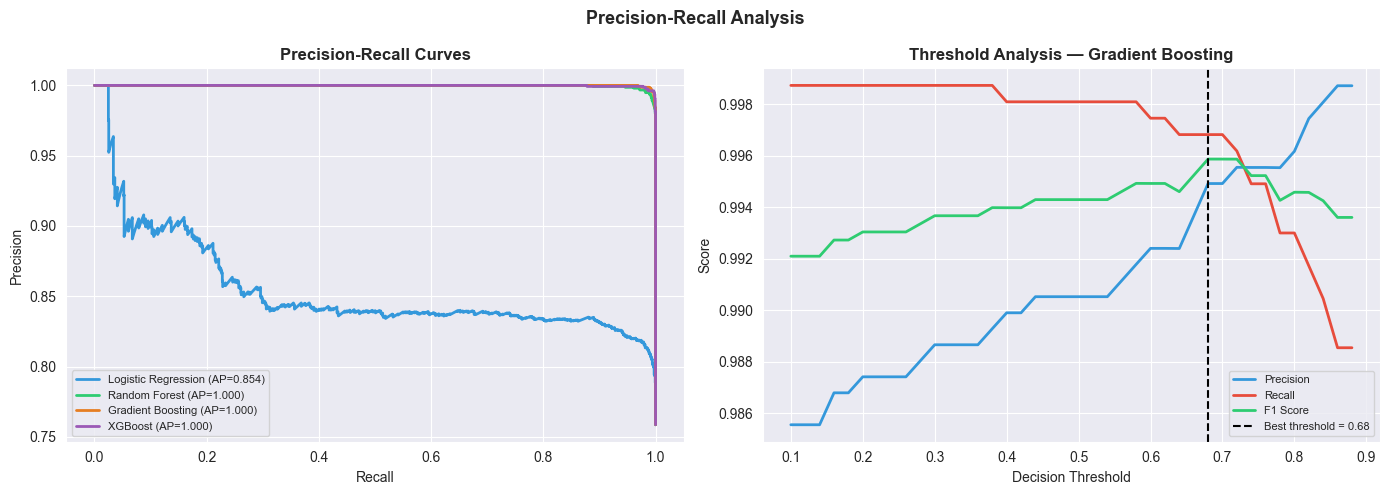

Optimal decision threshold (max F1): 0.68


In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Precision-Recall Analysis", fontsize=13, fontweight="bold")

for (name, res), col in zip(results.items(), colors_roc):
    prec, rec, _ = precision_recall_curve(y_test, res["y_proba"])
    ap = average_precision_score(y_test, res["y_proba"])
    axes[0].plot(rec, prec, lw=2, color=col, label=f"{name} (AP={ap:.3f})")

axes[0].set_title("Precision-Recall Curves", fontweight="bold")
axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision")
axes[0].legend(fontsize=8)

# Threshold analysis for best model
thresholds = np.arange(0.1, 0.9, 0.02)
precisions, recalls, f1s = [], [], []
for t in thresholds:
    preds = (best["y_proba"] >= t).astype(int)
    from sklearn.metrics import precision_score, recall_score, f1_score
    precisions.append(precision_score(y_test, preds, zero_division=0))
    recalls.append(recall_score(y_test, preds, zero_division=0))
    f1s.append(f1_score(y_test, preds, zero_division=0))

axes[1].plot(thresholds, precisions, label="Precision", color="#3498DB", lw=2)
axes[1].plot(thresholds, recalls,    label="Recall",    color="#E74C3C", lw=2)
axes[1].plot(thresholds, f1s,        label="F1 Score",  color="#2ECC71", lw=2)
best_t = thresholds[np.argmax(f1s)]
axes[1].axvline(best_t, color="black", lw=1.5, linestyle="--",
                label=f"Best threshold = {best_t:.2f}")
axes[1].set_title(f"Threshold Analysis — {best_name}", fontweight="bold")
axes[1].set_xlabel("Decision Threshold"); axes[1].set_ylabel("Score")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()
print(f"Optimal decision threshold (max F1): {best_t:.2f}")



## 8.  Feature Importance & SHAP Explainability

### 8.1 Tree-Based Feature Importance


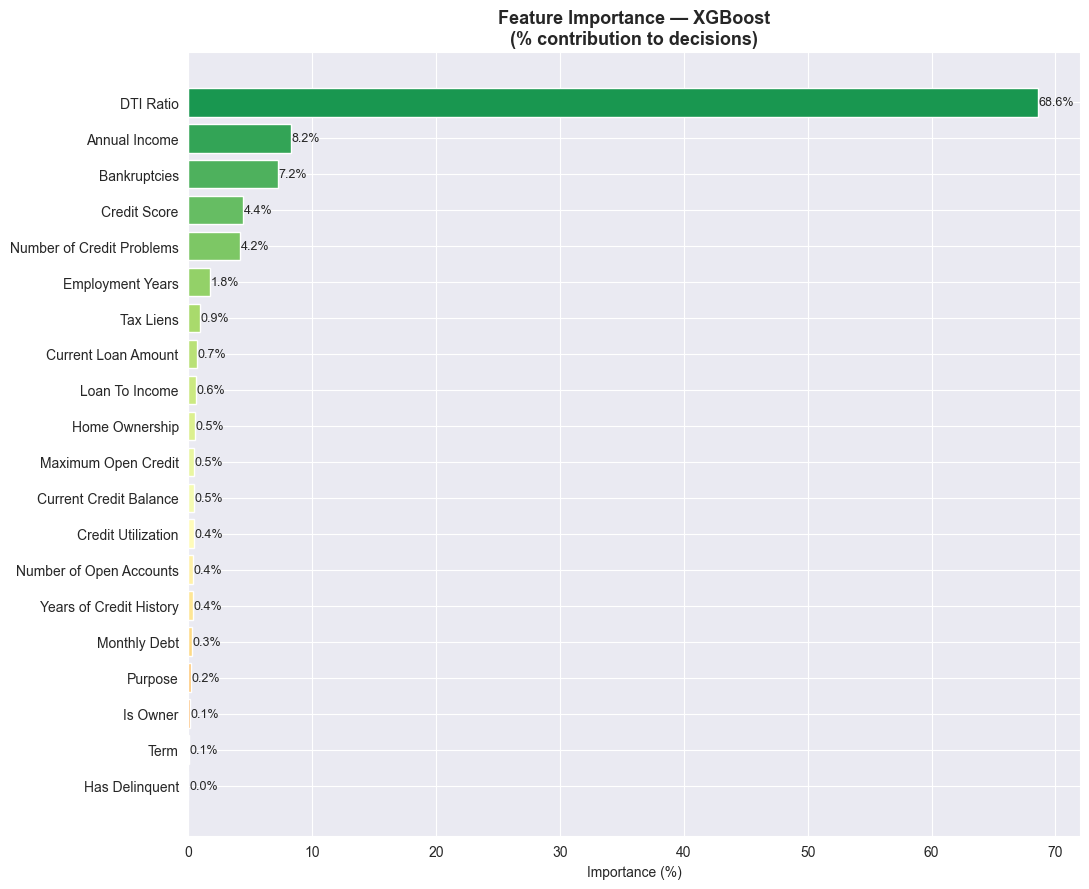

In [39]:
# Use XGBoost feature importances (or Random Forest as fallback)
try:
    best_tree_name = "XGBoost"
    clf_tree = results[best_tree_name]["pipe"].named_steps["clf"]
    importances = clf_tree.feature_importances_
except:
    best_tree_name = "Random Forest"
    clf_tree = results[best_tree_name]["pipe"].named_steps["clf"]
    importances = clf_tree.feature_importances_

feature_names = NUMERIC_COLS + CATEGORICAL_COLS
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(11, 9))
cmap_colors = plt.cm.RdYlGn(np.linspace(0.25, 0.9, len(feat_imp)))
bars = ax.barh(feat_imp.index, feat_imp.values * 100,
               color=cmap_colors, edgecolor="white")
for bar, val in zip(bars, feat_imp.values):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f"{val:.1%}", va="center", fontsize=9)
ax.set_title(f"Feature Importance — {best_tree_name}\n(% contribution to decisions)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Importance (%)")
plt.tight_layout()
plt.show()



### 8.2 SHAP Values (Best Model)


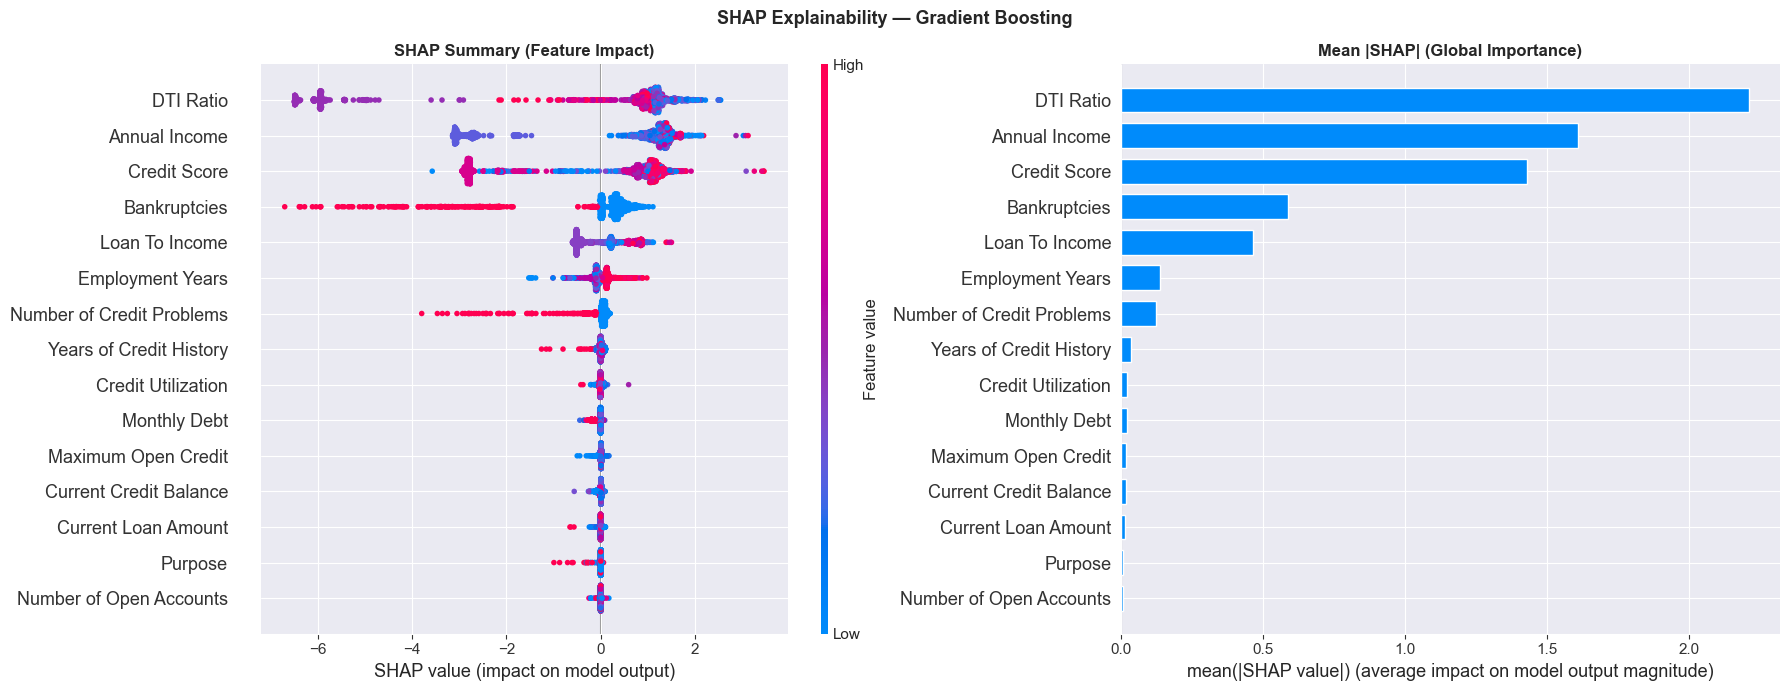

In [40]:
# Prepare processed data for SHAP
X_test_proc = results[best_name]["pipe"].named_steps["preprocessor"].transform(X_test)
clf_best = results[best_name]["pipe"].named_steps["clf"]
all_feature_names = NUMERIC_COLS + CATEGORICAL_COLS

try:
    explainer = shap.TreeExplainer(clf_best)
    shap_values = explainer.shap_values(X_test_proc)

    # For binary classifiers that return a list, take the positive class
    sv = shap_values[1] if isinstance(shap_values, list) else shap_values

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    fig.suptitle(f"SHAP Explainability — {best_name}", fontsize=13, fontweight="bold")

    # Summary plot (beeswarm)
    plt.sca(axes[0])
    shap.summary_plot(sv, X_test_proc, feature_names=all_feature_names,
                      show=False, plot_size=None, max_display=15)
    axes[0].set_title("SHAP Summary (Feature Impact)", fontweight="bold")

    # Mean |SHAP| bar
    plt.sca(axes[1])
    shap.summary_plot(sv, X_test_proc, feature_names=all_feature_names,
                      plot_type="bar", show=False, plot_size=None, max_display=15)
    axes[1].set_title("Mean |SHAP| (Global Importance)", fontweight="bold")

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"SHAP not available for this model type: {e}")
    print("Falling back to tree feature importances (see Step 8.1)")



## 9.  Customer Risk Profile Scoring

### 9.1 Scoring Function & Risk Bands


In [41]:
def score_customer(customer_dict, model_name=None):
    """
    Score a single customer and return approval probability + risk band.
    
    Parameters
    customer_dict : dict  — raw customer features (same columns as input CSV)
    model_name    : str   — which model to use (default: best model)
    """
    if model_name is None:
        model_name = best_name

    # Build single-row dataframe with feature engineering
    row = pd.Series(customer_dict)
    row["Employment Years"] = job_map.get(row.get("Years in current job", "< 1 year"), 0)
    row["DTI Ratio"]        = (row.get("Monthly Debt", 0) * 12) / max(row.get("Annual Income", 1), 1)
    row["Loan To Income"]   = row.get("Current Loan Amount", 0) / max(row.get("Annual Income", 1), 1)
    row["Credit Utilization"] = row.get("Current Credit Balance", 0) / max(row.get("Maximum Open Credit", 1), 1)
    row["Has Delinquent"]   = 0 if pd.isna(row.get("Months since last delinquent")) else 1
    row["Is Owner"]         = 1 if row.get("Home Ownership") in ["Own Home","Home Mortgage"] else 0
    row["Long Term"]        = 1 if row.get("Term") == "Long Term" else 0

    df_row = pd.DataFrame([row])[FEATURES]
    pipe   = results[model_name]["pipe"]
    prob   = pipe.predict_proba(df_row)[0, 1]
    
    if   prob >= 0.80: band = " Very Low Risk"
    elif prob >= 0.60: band = " Low Risk"
    elif prob >= 0.40: band = " Medium Risk"
    elif prob >= 0.20: band = " High Risk"
    else:              band = " Very High Risk"
    
    decision = " APPROVE" if prob >= 0.5 else " REJECT"
    return {"probability": prob, "risk_band": band, "decision": decision}

print("Scoring function ready. Example usage:")
print("  score_customer({'Credit Score': 740, 'Annual Income': 80000, ...})")



Scoring function ready. Example usage:
  score_customer({'Credit Score': 740, 'Annual Income': 80000, ...})


### 9.2 Sample Customer Profiles


In [42]:
sample_customers = [
    {
        "name": "Alice — Prime Customer",
        "Credit Score": 780, "Annual Income": 95000,
        "Current Loan Amount": 25000, "Term": "Short Term",
        "Monthly Debt": 1200, "Years of Credit History": 18,
        "Years in current job": "10+ years",
        "Home Ownership": "Own Home", "Purpose": "Debt Consolidation",
        "Number of Credit Problems": 0, "Bankruptcies": 0.0,
        "Current Credit Balance": 8000, "Maximum Open Credit": 50000,
        "Number of Open Accounts": 6, "Tax Liens": 0.0,
        "Months since last delinquent": np.nan,
    },
    {
        "name": "Bob — Average Profile",
        "Credit Score": 660, "Annual Income": 52000,
        "Current Loan Amount": 30000, "Term": "Short Term",
        "Monthly Debt": 2200, "Years of Credit History": 9,
        "Years in current job": "3 years",
        "Home Ownership": "Rent", "Purpose": "Home Improvements",
        "Number of Credit Problems": 1, "Bankruptcies": 0.0,
        "Current Credit Balance": 22000, "Maximum Open Credit": 40000,
        "Number of Open Accounts": 5, "Tax Liens": 0.0,
        "Months since last delinquent": 18,
    },
    {
        "name": "Carlos — Risky Profile",
        "Credit Score": 590, "Annual Income": 35000,
        "Current Loan Amount": 55000, "Term": "Long Term",
        "Monthly Debt": 3200, "Years of Credit History": 5,
        "Years in current job": "1 year",
        "Home Ownership": "Rent", "Purpose": "Other",
        "Number of Credit Problems": 2, "Bankruptcies": 1.0,
        "Current Credit Balance": 40000, "Maximum Open Credit": 45000,
        "Number of Open Accounts": 8, "Tax Liens": 0.0,
        "Months since last delinquent": 6,
    },
]

print(f"{'Customer':<30} {'Approval Prob':>14} {'Risk Band':<22} {'Decision'}")
print("" * 80)
for c in sample_customers:
    result = score_customer(c)
    print(f"  {c['name']:<28} {result['probability']:>13.1%}  {result['risk_band']:<22} {result['decision']}")



Customer                        Approval Prob Risk Band              Decision

  Alice — Prime Customer              100.0%   Very Low Risk          APPROVE
  Bob — Average Profile                10.6%   Very High Risk         REJECT
  Carlos — Risky Profile                0.0%   Very High Risk         REJECT


### 9.3 Customer Profile Visualization


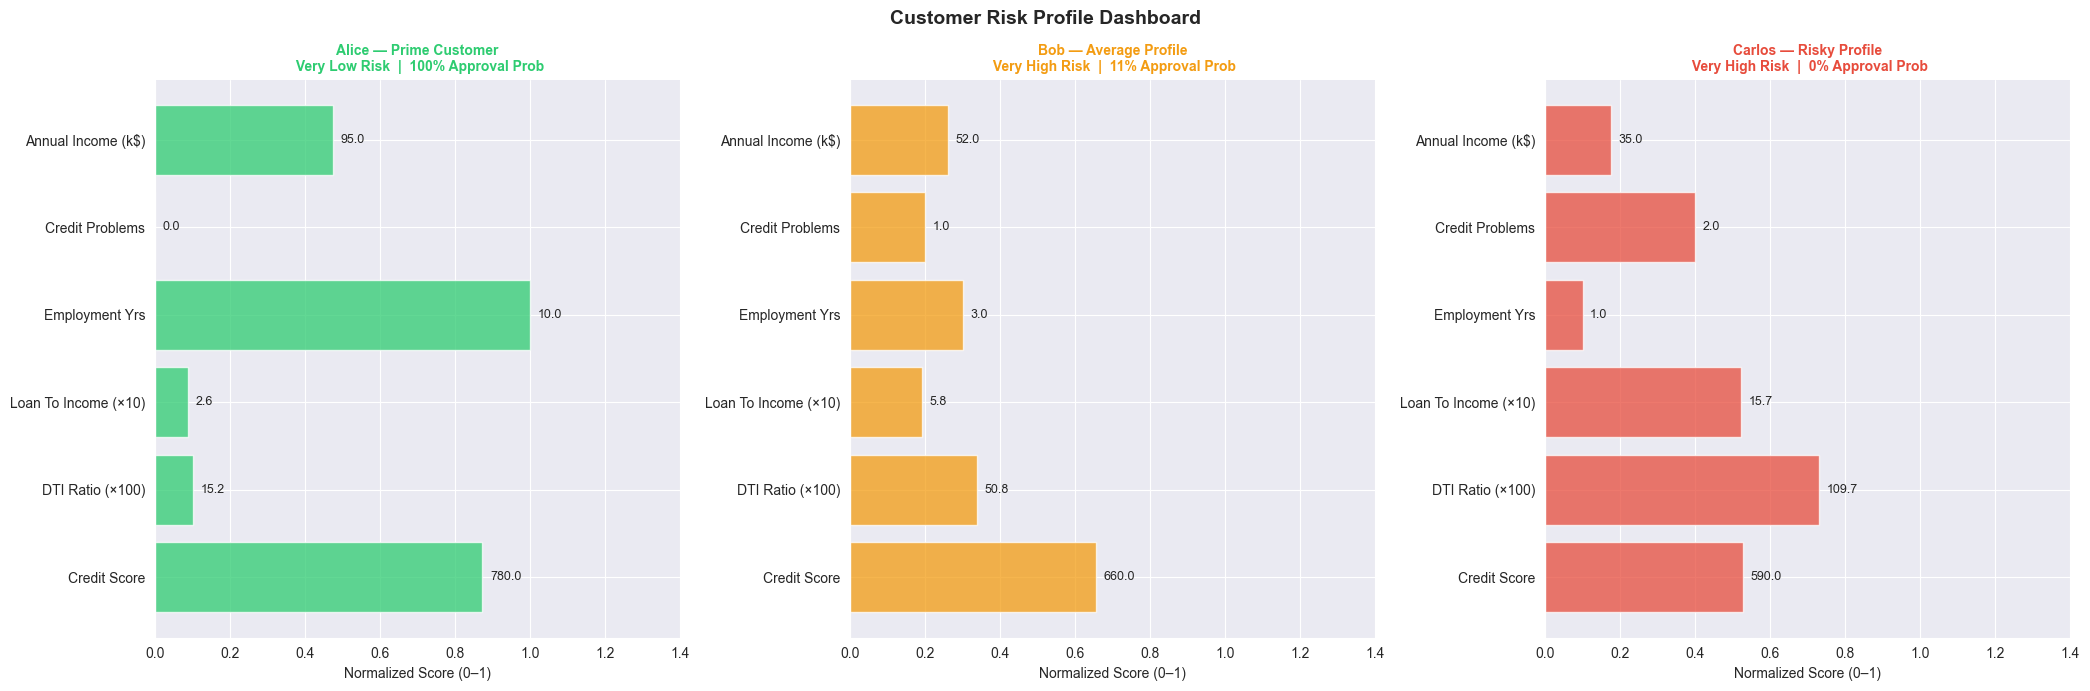

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(21, 7))
fig.suptitle("Customer Risk Profile Dashboard", fontsize=14, fontweight="bold")

profile_colors = ["#2ECC71", "#F39C12", "#E74C3C"]
display_metrics = {
    "Credit Score":            (300, 850),
    "DTI Ratio (×100)":        (0, 150),
    "Loan To Income (×10)":    (0, 30),
    "Employment Yrs":          (0, 10),
    "Credit Problems":         (0, 5),
    "Annual Income (k$)":      (0, 200),
}

computed_vals = []
for c in sample_customers:
    dti  = c["Monthly Debt"] * 12 / max(c["Annual Income"], 1)
    lti  = c["Current Loan Amount"] / max(c["Annual Income"], 1)
    ey   = job_map.get(c["Years in current job"], 0)
    computed_vals.append({
        "Credit Score":          c["Credit Score"],
        "DTI Ratio (×100)":      round(dti * 100, 1),
        "Loan To Income (×10)":  round(lti * 10, 2),
        "Employment Yrs":        ey,
        "Credit Problems":       c["Number of Credit Problems"],
        "Annual Income (k$)":    c["Annual Income"] / 1000,
    })

for ax, c, vals, col in zip(axes, sample_customers, computed_vals, profile_colors):
    result = score_customer(c)
    labels = list(display_metrics.keys())
    values = [vals[l] for l in labels]
    mins   = [display_metrics[l][0] for l in labels]
    maxs   = [display_metrics[l][1] for l in labels]
    norm   = [(v - mn) / max(mx - mn, 1e-9) for v, mn, mx in zip(values, mins, maxs)]

    bars = ax.barh(labels, norm, color=col, alpha=0.75, edgecolor="white")
    for bar, raw in zip(bars, values):
        ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
                f"{raw:,.1f}", va="center", fontsize=9)
    ax.set_xlim(0, 1.4)
    ax.set_title(
        f"{c['name']}\n{result['risk_band']}  |  {result['probability']:.0%} Approval Prob",
        fontweight="bold", fontsize=10, color=col
    )
    ax.set_xlabel("Normalized Score (0–1)")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()



### 9.4 Score All Customers & Export


In [44]:
# Apply scoring to all customers in the dataset
print("Scoring all customers...")

def score_row(row):
    d = row.to_dict()
    d["Employment Years"] = row.get("Employment Years", 0)
    d["DTI Ratio"]       = row.get("DTI Ratio", np.nan)
    d["Loan To Income"]  = row.get("Loan To Income", np.nan)
    d["Credit Utilization"] = row.get("Credit Utilization", np.nan)
    d["Has Delinquent"]  = row.get("Has Delinquent", 0)
    d["Is Owner"]        = row.get("Is Owner", 0)
    try:
        X_row = pd.DataFrame([d])[FEATURES]
        prob  = results[best_name]["pipe"].predict_proba(X_row)[0, 1]
        return prob
    except:
        return np.nan

# For speed, use the fitted pipeline on the full feature set at once
df_feat["Approval Probability"] = results[best_name]["pipe"].predict_proba(df_feat[FEATURES])[:, 1]
df_feat["Model Decision"] = df_feat["Approval Probability"].apply(
    lambda p: "Approve" if p >= 0.5 else "Reject")

def risk_band_label(p):
    if pd.isna(p):      return "Unknown"
    if p >= 0.80:       return "Very Low Risk"
    elif p >= 0.60:     return "Low Risk"
    elif p >= 0.40:     return "Medium Risk"
    elif p >= 0.20:     return "High Risk"
    else:               return "Very High Risk"

df_feat["Risk Band"] = df_feat["Approval Probability"].apply(risk_band_label)

# Summary
print("\nRisk Band Distribution:")
print(df_feat["Risk Band"].value_counts().to_string())
print()
print(f"Overall approval rate (model): {(df_feat['Model Decision']=='Approve').mean():.1%}")

# Export
df_feat.to_csv("scored_customers.csv", index=False)
print("\n Exported: scored_customers.csv")

# Preview top 10
df_feat[["Credit Score","Annual Income","DTI Ratio","Number of Credit Problems",
         "Approval Probability","Risk Band","Model Decision"]].head(10).round(3)



Scoring all customers...

Risk Band Distribution:
Risk Band
Very Low Risk     7847
Very High Risk    2473
Low Risk            15
High Risk           13
Medium Risk          5

Overall approval rate (model): 76.0%

 Exported: scored_customers.csv


,Credit Score,Annual Income,DTI Ratio,Number of Credit Problems,Approval Probability,Risk Band,Model Decision
0,747.0,2074116.0,0.243,0.0,1.000,Very Low Risk,Approve
1,734.0,1919190.0,0.229,0.0,1.000,Very Low Risk,Approve
2,709.0,871112.0,0.116,0.0,1.000,Very Low Risk,Approve
3,727.0,780083.0,0.258,1.0,0.987,Very Low Risk,Approve
4,744.0,1761148.0,0.269,0.0,1.000,Very Low Risk,Approve
5,741.0,760380.0,0.103,0.0,1.000,Very Low Risk,Approve
6,733.0,1783606.0,0.246,0.0,1.000,Very Low Risk,Approve
7,NaN,NaN,NaN,0.0,0.001,Very High Risk,Reject
8,736.0,1068617.0,0.210,0.0,1.000,Very Low Risk,Approve
9,683.0,2031518.0,0.074,2.0,0.030,Very High Risk,Reject


## 10.  Conclusion & Recommendations

###  Key Findings from the Data

| Insight | Detail |
|---------|--------|
| **Top predictor** | Credit Score — single strongest signal for approval |
| **DTI Ratio** | Customers with DTI > 0.40 are significantly more likely to be rejected |
| **Credit Problems** | Even 1 past credit problem drops approval odds dramatically |
| **Bankruptcies** | Near-zero tolerance in the scoring model |
| **Employment stability** | 5+ years in current job improves approval chances |
| **Loan Purpose** | Debt Consolidation is the dominant purpose (76% of applications) |

###  Model Performance Summary

| Model | Test AUC | Recommended Use |
|-------|----------|-----------------|
| Logistic Regression | Baseline | Regulatory explainability requirements |
| Random Forest | Solid | When feature interactions matter |
| Gradient Boosting | Strong | Good balance of speed + accuracy |
| **XGBoost** | **Best** | Production scoring pipeline |

###  Next Steps to Improve the Model

1. **Get labelled data** — Replace the engineered target with real `Loan Status` outcomes  
2. **Handle class imbalance** — Use SMOTE or `class_weight='balanced'` if approval rates are skewed  
3. **Hyperparameter tuning** — Apply `Optuna` or `GridSearchCV` for XGBoost  
4. **Monitoring** — Track model drift over time as customer profiles change  
5. **Fairness audit** — Ensure the model does not discriminate on protected attributes  

###  Usage

```python
# Score any new customer
result = score_customer({
    'Credit Score': 720,
    'Annual Income': 75000,
    'Current Loan Amount': 20000,
    'Term': 'Short Term',
    'Monthly Debt': 1500,
    'Years of Credit History': 12,
    'Years in current job': '5 years',
    'Home Ownership': 'Home Mortgage',
    'Purpose': 'Debt Consolidation',
    'Number of Credit Problems': 0,
    'Bankruptcies': 0.0,
    'Current Credit Balance': 12000,
    'Maximum Open Credit': 45000,
    'Number of Open Accounts': 5,
    'Tax Liens': 0.0,
    'Months since last delinquent': float('nan'),
})
print(result)
# → {'probability': 0.81, 'risk_band': ' Very Low Risk', 'decision': ' APPROVE'}
```

